In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets

from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

I0000 00:00:1777424277.004118   16437 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777424277.004785   16437 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777424277.281482   16437 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777424280.004353   16437 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
def symmetric_batch_schedule(base, depth, multiplier=2): 
	seq = [base] 
	for d in range(1, depth + 1):
		seq = seq + [base * multiplier**d] + seq[::-1] 
	return np.array(seq)

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()
y_train = y_train.squeeze()
y_test = y_test.squeeze()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=RANDOM_STATE)

/home/ottenl/classwork/CSC5611/venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal', seed=RANDOM_STATE),
    layers.RandomTranslation(0.1, 0.1, seed=RANDOM_STATE + 1),
    layers.RandomZoom(0.1, seed=RANDOM_STATE + 2),
], name='data_augmentation')

def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = layers.Conv2D(32, 3, padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = residual_block(x, 32)
x = residual_block(x, 32)
x = residual_block(x, 64, stride=2)
x = residual_block(x, 64)
x = residual_block(x, 128, stride=2)
x = residual_block(x, 128)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(100, activation='softmax')(x)

model = keras.Model(inputs, outputs, name='small_resnet')
model_sleep = tf.keras.models.clone_model(model)
model_sleep.set_weights(model.get_weights())
model_min = tf.keras.models.clone_model(model)
model_min.set_weights(model.get_weights())
model_max = tf.keras.models.clone_model(model)
model_max.set_weights(model.get_weights())
model_adam = tf.keras.models.clone_model(model)
model_adam.set_weights(model.get_weights())
model_sleep_adam = tf.keras.models.clone_model(model)
model_sleep_adam.set_weights(model.get_weights())

In [ ]:
INITIAL_LR = 0.01
STEP_DECAY_EPOCHS = 5
STEP_DECAY_FACTOR = 0.5

def step_decay(epoch, initial_lr=INITIAL_LR, drop=STEP_DECAY_FACTOR, epochs_drop=STEP_DECAY_EPOCHS):
    return initial_lr * (drop ** (epoch // epochs_drop))

def set_optimizer_learning_rate(optimizer, learning_rate):
    if hasattr(optimizer.learning_rate, 'assign'):
        optimizer.learning_rate.assign(learning_rate)
    else:
        optimizer.learning_rate = learning_rate

model.compile(optimizer=keras.optimizers.SGD(learning_rate=INITIAL_LR, momentum=0.9, nesterov=True), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_sleep.compile(optimizer=keras.optimizers.SGD(learning_rate=INITIAL_LR, momentum=0.9, nesterov=True), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_min.compile(optimizer=keras.optimizers.SGD(learning_rate=INITIAL_LR, momentum=0.9, nesterov=True), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_max.compile(optimizer=keras.optimizers.SGD(learning_rate=INITIAL_LR, momentum=0.9, nesterov=True), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_adam.compile(optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_sleep_adam.compile(optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
batch_schedule = symmetric_batch_schedule(base=64, depth=3)
print("Batch schedule:", batch_schedule)
print(f"Mean batch size: {batch_schedule.mean():.2f}")
print("Dataset size:", len(x_train))

# Simple, deterministic augmentation for interpretability.
x_train_aug = np.concatenate([x_train, np.flip(x_train, axis=2)], axis=0)
y_train_aug = np.concatenate([y_train, y_train], axis=0)
print("Augmented train size:", len(x_train_aug))

baseline_batch_size = int(batch_schedule.mean())
min_batch_size = int(batch_schedule.min())
max_batch_size = int(batch_schedule.max())
adam_batch_size = baseline_batch_size

model_histories = []
model_sleep_histories = []
model_min_histories = []
model_max_histories = []
model_adam_histories = []
model_sleep_adam_histories = []

for epoch, bs in enumerate(batch_schedule):
    print(f"\nEpoch {epoch+1}, batch_size={bs}")

    current_lr = step_decay(epoch)

    set_optimizer_learning_rate(model.optimizer, current_lr)
    model_history = model.fit(
        x_train_aug,
        y_train_aug,
        validation_data=(x_val, y_val),
        epochs=1,
        batch_size=baseline_batch_size,
        shuffle=True,
        verbose=1
    )
    model_histories.append(model_history)

    set_optimizer_learning_rate(model_sleep.optimizer, current_lr)
    model_sleep_history = model_sleep.fit(
        x_train_aug,
        y_train_aug,
        validation_data=(x_val, y_val),
        epochs=1,
        batch_size=bs,
        shuffle=True,
        verbose=1
    )
    model_sleep_histories.append(model_sleep_history)

    set_optimizer_learning_rate(model_min.optimizer, current_lr)
    model_min_history = model_min.fit(
        x_train_aug,
        y_train_aug,
        validation_data=(x_val, y_val),
        epochs=1,
        batch_size=min_batch_size,
        shuffle=True,
        verbose=1
    )
    model_min_histories.append(model_min_history)

    set_optimizer_learning_rate(model_max.optimizer, current_lr)
    model_max_history = model_max.fit(
        x_train_aug,
        y_train_aug,
        validation_data=(x_val, y_val),
        epochs=1,
        batch_size=max_batch_size,
        shuffle=True,
        verbose=1
    )
    model_max_histories.append(model_max_history)

    model_adam_history = model_adam.fit(
        x_train_aug,
        y_train_aug,
        validation_data=(x_val, y_val),
        epochs=1,
        batch_size=adam_batch_size,
        shuffle=True,
        verbose=1
    )
    model_adam_histories.append(model_adam_history)

    model_sleep_adam_history = model_sleep_adam.fit(
        x_train_aug,
        y_train_aug,
        validation_data=(x_val, y_val),
        epochs=1,
        batch_size=bs,
        shuffle=True,
        verbose=1
    )
    model_sleep_adam_histories.append(model_sleep_adam_history)


Batch schedule: [ 64 128  64 256  64 128  64 512  64 128  64 256  64 128  64]
Mean batch size: 136.53
Dataset size: 40000

Epoch 1, batch_size=64
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 131ms/step - accuracy: 0.0841 - loss: 3.9966 - val_accuracy: 0.1071 - val_loss: 3.7932

Epoch 2, batch_size=128
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 216ms/step - accuracy: 0.1699 - loss: 3.4143 - val_accuracy: 0.2087 - val_loss: 3.2454

Epoch 3, batch_size=64
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 153ms/step - accuracy: 0.2026 - loss: 3.2197 - val_accuracy: 0.2548 - val_loss: 2.9504

Epoch 4, batch_size=256
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 378ms/step - accuracy: 0.2603 - loss: 2.9046 - val_accuracy: 0.2793 - val_loss: 2.8621

Epoch 5, batch_size=64
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 132ms/step - accuracy: 0.2557 - loss: 2.9369 - val_accuracy: 0.2882 - val_loss: 2.7932

Epoch 6, batch_size=128
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 231ms/step - accuracy: 0.3010 - loss: 2.7088 - val_accuracy: 0.3192 - val_loss: 2.5940

Epoch 7, b

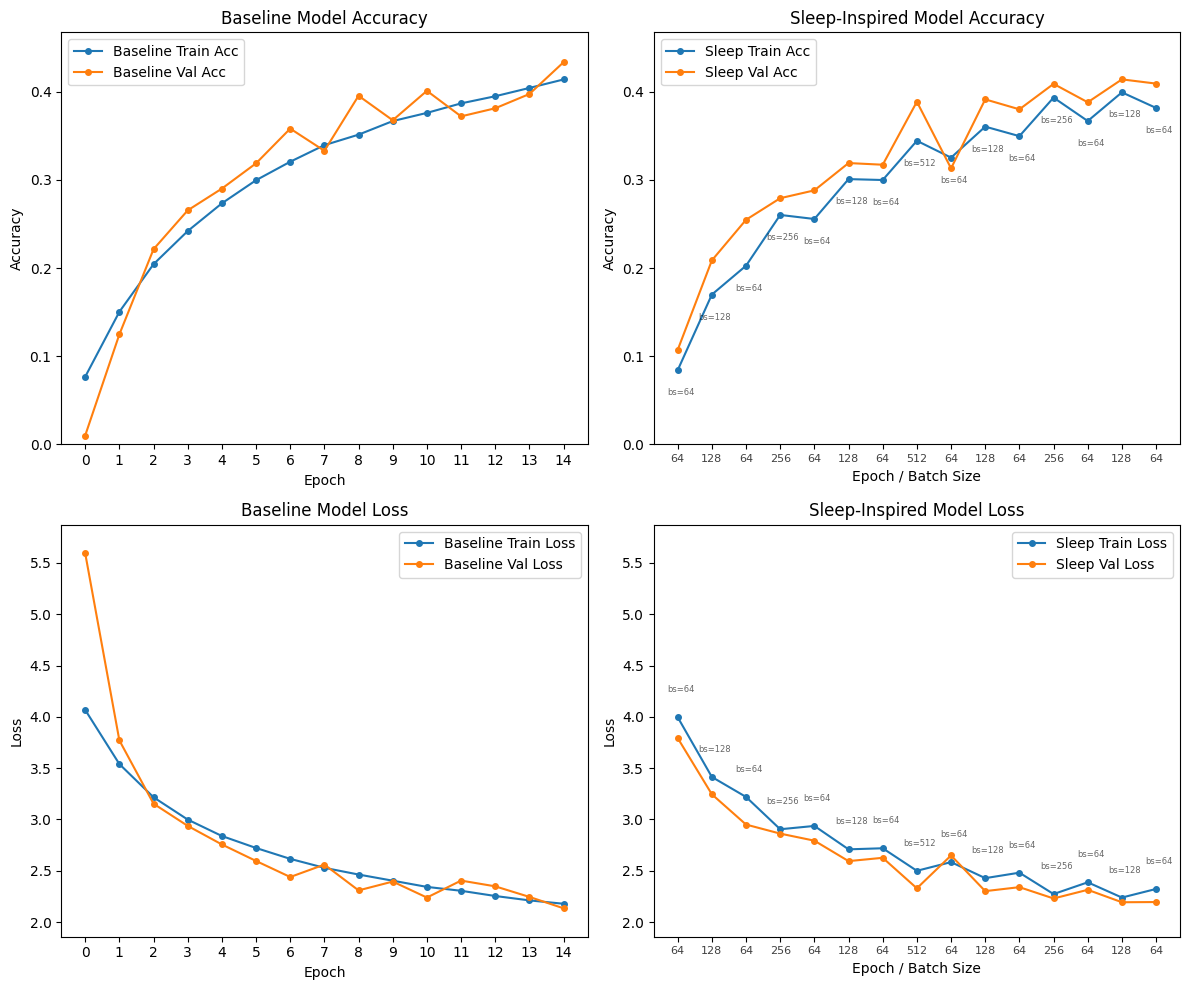

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

baseline_train_acc = [h.history['accuracy'][0] for h in model_histories]
baseline_val_acc = [h.history['val_accuracy'][0] for h in model_histories]
ax[0][0].plot(baseline_train_acc, marker='o', markersize=4, label='Baseline Train Acc')
ax[0][0].plot(baseline_val_acc, marker='o', markersize=4, label='Baseline Val Acc')
ax[0][0].set_title('Baseline Model Accuracy')
ax[0][0].set_xlabel('Epoch')
ax[0][0].set_ylabel('Accuracy')
ax[0][0].legend()

sleep_train_acc = [h.history['accuracy'][0] for h in model_sleep_histories]
sleep_val_acc = [h.history['val_accuracy'][0] for h in model_sleep_histories]
ax[0][1].plot(sleep_train_acc, marker='o', markersize=4, label='Sleep Train Acc')
ax[0][1].plot(sleep_val_acc, marker='o', markersize=4, label='Sleep Val Acc')
ax[0][1].set_title('Sleep-Inspired Model Accuracy')
ax[0][1].set_xlabel('Epoch / Batch Size')
ax[0][1].set_ylabel('Accuracy')
ax[0][1].legend()

acc_values = baseline_train_acc + baseline_val_acc + sleep_train_acc + sleep_val_acc
acc_min = min(acc_values)
acc_max = max(acc_values)
acc_pad = max(0.01, (acc_max - acc_min) * 0.08)
acc_ylim = (max(0.0, acc_min - acc_pad), min(1.0, acc_max + acc_pad))
ax[0][0].set_ylim(*acc_ylim)
ax[0][1].set_ylim(*acc_ylim)

ax[0][0].set_xticks(range(len(baseline_train_acc)))
ax[0][1].set_xticks(range(len(batch_schedule)))
ax[0][1].set_xticklabels([f'{bs}' for bs in batch_schedule], fontsize=8)
for tick_label in ax[0][1].get_xticklabels():
    tick_label.set_alpha(0.75)

for index, batch_size in enumerate(batch_schedule):
    ax[0][1].annotate(
        f'bs={batch_size}',
        (index, sleep_train_acc[index]),
        textcoords='offset points',
        xytext=(0, -18),
        ha='center',
        fontsize=6,
        alpha=0.6,
    )

baseline_train_loss = [h.history['loss'][0] for h in model_histories]
baseline_val_loss = [h.history['val_loss'][0] for h in model_histories]
ax[1][0].plot(baseline_train_loss, marker='o', markersize=4, label='Baseline Train Loss')
ax[1][0].plot(baseline_val_loss, marker='o', markersize=4, label='Baseline Val Loss')
ax[1][0].set_title('Baseline Model Loss')
ax[1][0].set_xlabel('Epoch')
ax[1][0].set_ylabel('Loss')
ax[1][0].legend()

sleep_train_loss = [h.history['loss'][0] for h in model_sleep_histories]
sleep_val_loss = [h.history['val_loss'][0] for h in model_sleep_histories]
ax[1][1].plot(sleep_train_loss, marker='o', markersize=4, label='Sleep Train Loss')
ax[1][1].plot(sleep_val_loss, marker='o', markersize=4, label='Sleep Val Loss')
ax[1][1].set_title('Sleep-Inspired Model Loss')
ax[1][1].set_xlabel('Epoch / Batch Size')
ax[1][1].set_ylabel('Loss')
ax[1][1].legend()

for index, batch_size in enumerate(batch_schedule):
    ax[1][1].annotate(
        f'bs={batch_size}',
        (index, sleep_train_loss[index]),
        textcoords='offset points',
        xytext=(0, 18),
        ha='center',
        fontsize=6,
        alpha=0.6,
    )

loss_values = baseline_train_loss + baseline_val_loss + sleep_train_loss + sleep_val_loss
loss_min = min(loss_values)
loss_max = max(loss_values)
loss_pad = max(0.01, (loss_max - loss_min) * 0.08)
loss_ylim = (max(0.0, loss_min - loss_pad), loss_max + loss_pad)
ax[1][0].set_ylim(*loss_ylim)
ax[1][1].set_ylim(*loss_ylim)

ax[1][0].set_xticks(range(len(baseline_train_loss)))
ax[1][1].set_xticks(range(len(batch_schedule)))
ax[1][1].set_xticklabels([f'{bs}' for bs in batch_schedule], fontsize=8)
for tick_label in ax[1][1].get_xticklabels():
    tick_label.set_alpha(0.75)

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Baseline Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

test_loss_sleep, test_acc_sleep = model_sleep.evaluate(x_test, y_test, verbose=0)
print(f"Sleep-Inspired Test Accuracy: {test_acc_sleep:.4f}, Test Loss: {test_loss_sleep:.4f}")

test_loss_min, test_acc_min = model_min.evaluate(x_test, y_test, verbose=0)
print(f"Min Batch Size Test Accuracy: {test_acc_min:.4f}, Test Loss: {test_loss_min:.4f}")

test_loss_max, test_acc_max = model_max.evaluate(x_test, y_test, verbose=0)
print(f"Max Batch Size Test Accuracy: {test_acc_max:.4f}, Test Loss: {test_loss_max:.4f}")

test_loss_adam, test_acc_adam = model_adam.evaluate(x_test, y_test, verbose=0)
print(f"Adam Baseline Test Accuracy: {test_acc_adam:.4f}, Test Loss: {test_loss_adam:.4f}")

test_loss_sleep_adam, test_acc_sleep_adam = model_sleep_adam.evaluate(x_test, y_test, verbose=0)
print(f"Sleep-Inspired Adam Test Accuracy: {test_acc_sleep_adam:.4f}, Test Loss: {test_loss_sleep_adam:.4f}")

Baseline Test Accuracy: 0.4343, Test Loss: 2.1214
Sleep-Inspired Test Accuracy: 0.4062, Test Loss: 2.2168


In [ ]:
baseline_train_acc = [h.history['accuracy'][0] for h in model_histories]
baseline_val_acc = [h.history['val_accuracy'][0] for h in model_histories]
sleep_train_acc = [h.history['accuracy'][0] for h in model_sleep_histories]
sleep_val_acc = [h.history['val_accuracy'][0] for h in model_sleep_histories]
max_train_acc = [h.history['accuracy'][0] for h in model_max_histories]
max_val_acc = [h.history['val_accuracy'][0] for h in model_max_histories]
min_train_acc = [h.history['accuracy'][0] for h in model_min_histories]
min_val_acc = [h.history['val_accuracy'][0] for h in model_min_histories]
adam_train_acc = [h.history['accuracy'][0] for h in model_adam_histories]
adam_val_acc = [h.history['val_accuracy'][0] for h in model_adam_histories]
sleep_adam_train_acc = [h.history['accuracy'][0] for h in model_sleep_adam_histories]
sleep_adam_val_acc = [h.history['val_accuracy'][0] for h in model_sleep_adam_histories]

fig, ax = plt.subplots(figsize=(3, 1))
ax[0].plot(batch_schedule, baseline_train_acc, marker='o', label='Baseline Train Acc')
ax[0].plot(batch_schedule, sleep_train_acc, marker='o', label='Sleep Train Acc')
ax[0].plot(batch_schedule, max_train_acc, marker='o', label='Max Train Acc')
ax[0].plot(batch_schedule, min_train_acc, marker='o', label='Min Train Acc')
ax[0].plot(batch_schedule, adam_train_acc, marker='o', label='Adam Train Acc')
ax[0].plot(batch_schedule, sleep_adam_train_acc, marker='o', label='Sleep Adam Train Acc')
ax[0].set_title('Train Accuracy')
ax[0].set_xlabel('Batch Size')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(batch_schedule, baseline_val_acc, marker='o', label='Baseline Val Acc')
ax[1].plot(batch_schedule, sleep_val_acc, marker='o', label='Sleep Val Acc')
ax[1].plot(batch_schedule, max_val_acc, marker='o', label='Max Val Acc')
ax[1].plot(batch_schedule, min_val_acc, marker='o', label='Min Val Acc')
ax[1].plot(batch_schedule, adam_val_acc, marker='o', label='Adam Val Acc')
ax[1].plot(batch_schedule, sleep_adam_val_acc, marker='o', label='Sleep Adam Val Acc')
ax[1].set_title('Validation Accuracy')
ax[1].set_xlabel('Batch Size')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()